<a href="https://colab.research.google.com/github/tillurakesh3/Rakesh_INFO5731_Fall2024/blob/main/INFO5731_Assignment_2_final_(1)_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [1]:
# Write your code here
import pandas as pd
import re
from collections import Counter
import spacy

# 1. SETUP & DATA LOADING
# Replace this filename with your actual dataset file
FILE_NAME = 'cleaned_research_data (1).csv'
df = pd.read_csv(FILE_NAME)

# Use the first 100 entries (reviews/abstracts)
num_reviews = min(100, len(df))
subset = df.head(num_reviews).copy()
# Using the 'Abstract' column for raw text processing
texts = subset['Abstract'].fillna('').tolist()

# 2. TOKENIZATION & N-GRAMS FROM SCRATCH
def scratch_tokenize(text):
    """Lowercase and extract words using regex (from scratch)"""
    text = text.lower()
    return re.findall(r'\b\w+\b', text)

def get_ngrams(tokens, n):
    """Generate n-gram tuples from a list of tokens"""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

all_tokens = []
review_tokens_list = []

for t in texts:
    toks = scratch_tokenize(t)
    all_tokens.extend(toks)
    review_tokens_list.append(toks)

# (1) Frequency of N-grams (N=2 and N=3)
bigrams = get_ngrams(all_tokens, 2)
trigrams = get_ngrams(all_tokens, 3)

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)
unigram_counts = Counter(all_tokens)

print(f"Top 5 Bigrams: {bigram_counts.most_common(5)}")
print(f"Top 5 Trigrams: {trigram_counts.most_common(5)}")

# (2) Bigram Probabilities: count(w1 w2) / count(w1)
bigram_probabilities = {}
for bg, count in bigram_counts.items():
    w1 = bg[0]
    bigram_probabilities[bg] = count / unigram_counts[w1]

# Display sample probabilities
print("\nSample Bigram Probabilities:")
for bg, prob in list(bigram_probabilities.items())[:5]:
    print(f"P({bg[1]} | {bg[0]}) = {prob:.4f}")

# (3) NOUN PHRASE EXTRACTION & RELATIVE PROBABILITIES
# To run this, install: pip install spacy && python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

review_np_counts = []
all_unique_nps = set()

for t in texts:
    doc = nlp(t)
    nps = [chunk.text.lower().strip() for chunk in doc.noun_chunks]
    counts = Counter(nps)
    review_np_counts.append(counts)
    all_unique_nps.update(nps)

unique_nps_list = sorted(list(all_unique_nps))

# Calculate global max frequency for each Noun Phrase
max_frequencies = {np_name: 0 for np_name in unique_nps_list}
for counts in review_np_counts:
    for np_name, freq in counts.items():
        if freq > max_frequencies[np_name]:
            max_frequencies[np_name] = freq

# Calculate relative probabilities: frequency(NP) / max_frequency(NP)
table_data = []
for counts in review_np_counts:
    row = []
    for np_name in unique_nps_list:
        max_f = max_frequencies[np_name]
        rel_prob = counts[np_name] / max_f if max_f > 0 else 0
        row.append(round(rel_prob, 4))
    table_data.append(row)

# Construct final DataFrame table
np_matrix_df = pd.DataFrame(table_data, columns=unique_nps_list)
np_matrix_df.index = [f"Review_{i+1}" for i in range(num_reviews)]

# Output the table
print("\nNoun Phrase Relative Probability Table (Partial View):")
print(np_matrix_df.iloc[:10, :5])  # Display first 10 rows and 5 columns

# Save full table to CSV
np_matrix_df.to_csv('noun_phrase_analysis_results.csv')





Top 5 Bigrams: [(('of', 'the'), 136), (('machine', 'learning'), 113), (('in', 'the'), 91), (('based', 'on'), 46), (('and', 'the'), 46)]
Top 5 Trigrams: [(('in', 'this', 'paper'), 17), (('a', 'machine', 'learning'), 14), (('machine', 'learning', 'models'), 13), (('machine', 'learning', 'algorithms'), 13), (('of', 'machine', 'learning'), 13)]

Sample Bigram Probabilities:
P(the | in) = 0.2182
P(era | the) = 0.0016
P(of | era) = 0.5000
P(burgeoning | of) = 0.0014
P(electric | burgeoning) = 1.0000

Noun Phrase Relative Probability Table (Partial View):
            $m  %incmse  (0,5%  (1) caracterização  (1) health prevention
Review_1   0.0      0.0    0.0                 0.0                    0.0
Review_2   0.0      0.0    0.0                 0.0                    0.0
Review_3   0.0      0.0    0.0                 0.0                    0.0
Review_4   0.0      0.0    0.0                 0.0                    0.0
Review_5   0.0      0.0    0.0                 0.0                    0.0
R

## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [2]:
# Write your code here
import pandas as pd
import math
import re
from collections import Counter

# 1. SETUP & DATA LOADING
file_path = 'cleaned_research_data (1).csv'
df = pd.read_csv(file_path)

# Using the first 100 entries (Abstracts) for analysis
num_docs = min(100, len(df))
subset = df.head(num_docs).copy()
documents = subset['Abstract'].fillna('').tolist()

def tokenize(text):
    """Lowercases and extracts alphanumeric words using regex."""
    text = str(text).lower()
    return re.findall(r'\b\w+\b', text)

# Pre-tokenize all documents
tokenized_docs = [tokenize(doc) for doc in documents]
# Build a vocabulary of all unique words
vocabulary = sorted(list(set(token for doc in tokenized_docs for token in doc)))

# 2. BUILDING THE TF-IDF MATRIX FROM SCRATCH

# IDF calculation: log(Total Documents / Documents containing the term)
def calculate_idf(tokenized_docs, vocab):
    idf_dict = {}
    total_n = len(tokenized_docs)
    for term in vocab:
        # Count how many docs contain the word
        docs_with_term = sum(1 for doc in tokenized_docs if term in doc)
        # Using base-10 log; smoothing is implicit here by ensuring docs_with_term > 0
        idf_dict[term] = math.log10(total_n / (docs_with_term if docs_with_term > 0 else 1))
    return idf_dict

idf_scores = calculate_idf(tokenized_docs, vocabulary)

# TF-IDF calculation for a single document
def calculate_tfidf(tokenized_doc, idf_scores):
    tfidf_vector = {}
    counts = Counter(tokenized_doc)
    doc_len = len(tokenized_doc)
    for term, count in counts.items():
        if term in idf_scores:
            tf = count / doc_len
            tfidf_vector[term] = tf * idf_scores[term]
    return tfidf_vector

# Generate TF-IDF weights for all documents
tfidf_matrix = [calculate_tfidf(doc, idf_scores) for doc in tokenized_docs]

# 3. QUERY RANKING USING COSINE SIMILARITY

# Designed Query
user_query = "Machine learning applications in medical research and disease diagnosis"
query_tokens = tokenize(user_query)
query_tfidf = calculate_tfidf(query_tokens, idf_scores)

def cosine_similarity(vec1, vec2):
    """Calculates cosine similarity between two sparse dict-based vectors."""
    # Dot product calculation
    dot_product = 0
    common_terms = set(vec1.keys()) & set(vec2.keys())
    for term in common_terms:
        dot_product += vec1[term] * vec2[term]

    # Norm calculation
    norm1 = sum(val**2 for val in vec1.values()) ** 0.5
    norm2 = sum(val**2 for val in vec2.values()) ** 0.5

    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot_product / (norm1 * norm2)

# Calculate similarity scores for all documents
rankings = []
for i, doc_vec in enumerate(tfidf_matrix):
    score = cosine_similarity(query_tfidf, doc_vec)
    rankings.append((i, score))

# Rank results by score in descending order
ranked_results = sorted(rankings, key=lambda x: x[1], reverse=True)

# 4. OUTPUT RESULTS
print(f"Query: '{user_query}'\n")
print("-" * 80)
print(f"{'Rank':<5} | {'Similarity':<10} | {'Document Title'}")
print("-" * 80)

for rank, (idx, score) in enumerate(ranked_results[:10], 1):
    title = subset.iloc[idx]['Title']
    print(f"{rank:<5} | {score:<10.4f} | {title}")

# Save the sparse matrix to a file (Documents as Rows, Words as Columns)
tfidf_df = pd.DataFrame(tfidf_matrix).fillna(0)
tfidf_df.index = [f"Document_{i+1}" for i in range(num_docs)]
tfidf_df.to_csv('tfidf_matrix.csv')






Query: 'Machine learning applications in medical research and disease diagnosis'

--------------------------------------------------------------------------------
Rank  | Similarity | Document Title
--------------------------------------------------------------------------------
1     | 0.2170     | Smart Diagnosis of Disease Using Machine Learning
2     | 0.1715     | Evaluation of Convolutional Neural Network Model and Various Machine Learning Models for Decision-Making in the Health Care Industry
3     | 0.1516     | Convolutional Neural Network Techniques on X-ray Images for Covid-19 Classification
4     | 0.1187     | AI Assisted Heart Disease Prediction and Classification and Segmentation based on PIMA and UCI Machine Learning Datasets
5     | 0.0938     | Machine learning practices in accounting and auditing
6     | 0.0824     | Diabetic Detection from Images of the Eye
7     | 0.0670     | At the Confluence of Artificial Intelligence and Edge Computing in IoT-Based Applications

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.9 MB/s eta 0:00:00
Cosine Similarities:
Similarity(machine, learning) = 0.2907
Similarity(medical, health) = 0.8327
Similarity(electric, vehicle) = 0.9279
Similarity(machine, energy) = 0.1538
Similarity(data, algorithm) = 0.4106
Total words in vocabulary: 22935
Words used for plotting: 25


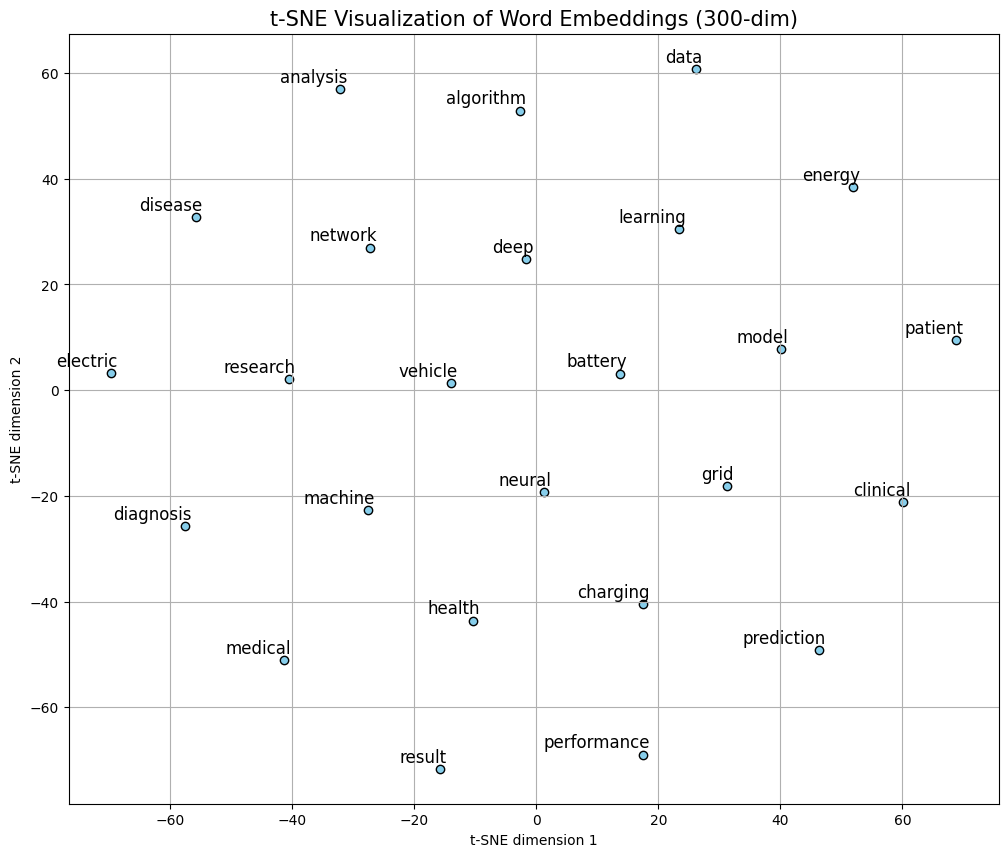

In [5]:
# Install gensim if not already installed
!pip install gensim

import pandas as pd
import re
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
file_path = 'cleaned_research_data (1).csv'
df = pd.read_csv(file_path)

# Use 'Clean_Text' column for training
# If Clean_Text is empty for some rows, drop them
data = df['Clean_Text'].dropna().tolist()

# Tokenize the text
tokenized_data = [str(text).split() for text in data]

# (1) Train a 300-dimensional Word2Vec model
# vector_size=300, window=5, min_count=2 (to ensure we have enough words to plot)
model = Word2Vec(sentences=tokenized_data, vector_size=300, window=5, min_count=2, workers=4)

# (2) Visualize the embeddings using t-SNE
# Select at least 20 words. Let's pick some common and meaningful ones from the corpus.
# We can find words related to the queries or high-frequency words.
vocab = list(model.wv.key_to_index.keys())
# Pick some words that likely cluster together
target_words = ['machine', 'learning', 'deep', 'algorithm', 'data', 'model', 'neural', 'network',
                'medical', 'health', 'disease', 'diagnosis', 'clinical', 'patient',
                'electric', 'vehicle', 'energy', 'charging', 'grid', 'battery',
                'research', 'analysis', 'prediction', 'result', 'performance']

# Ensure words are in vocab
words_to_plot = [w for w in target_words if w in model.wv]
word_vectors = np.array([model.wv[w] for w in words_to_plot])

# Use t-SNE for dimension reduction to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=len(words_to_plot)-1)
vectors_2d = tsne.fit_transform(word_vectors)

# Create scatter plot
plt.figure(figsize=(12, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='skyblue')

for i, word in enumerate(words_to_plot):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom', fontsize=12)

plt.title('t-SNE Visualization of Word Embeddings (300-dim)', fontsize=15)
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(True)
plt.savefig('word_embeddings_tsne.png')

# (3) Calculate cosine similarity between pairs of words
pairs = [
    ('machine', 'learning'),
    ('medical', 'health'),
    ('electric', 'vehicle'),
    ('machine', 'energy'), # Should be low
    ('data', 'algorithm')
]

similarities = []
for w1, w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        similarities.append((w1, w2, sim))

print("Cosine Similarities:")
for w1, w2, sim in similarities:
    print(f"Similarity({w1}, {w2}) = {sim:.4f}")

# Reiterate result for user
print(f"Total words in vocabulary: {len(vocab)}")
print(f"Words used for plotting: {len(words_to_plot)}")

Word Pairs and Cosine Similarities:
Similarity(machine, learning) = 0.2338
Similarity(neural, network) = 0.5272
Similarity(medical, health) = 0.8062
Similarity(data, robot) = 0.4363
Similarity(prediction, classification) = 0.7679

Most similar to 'learning':
[('learningbased', 0.8652223944664001), ('boltzmann', 0.8269441723823547), ('helmholtz', 0.8095619678497314), ('ml', 0.788664698600769), ('translation', 0.7731932997703552)]


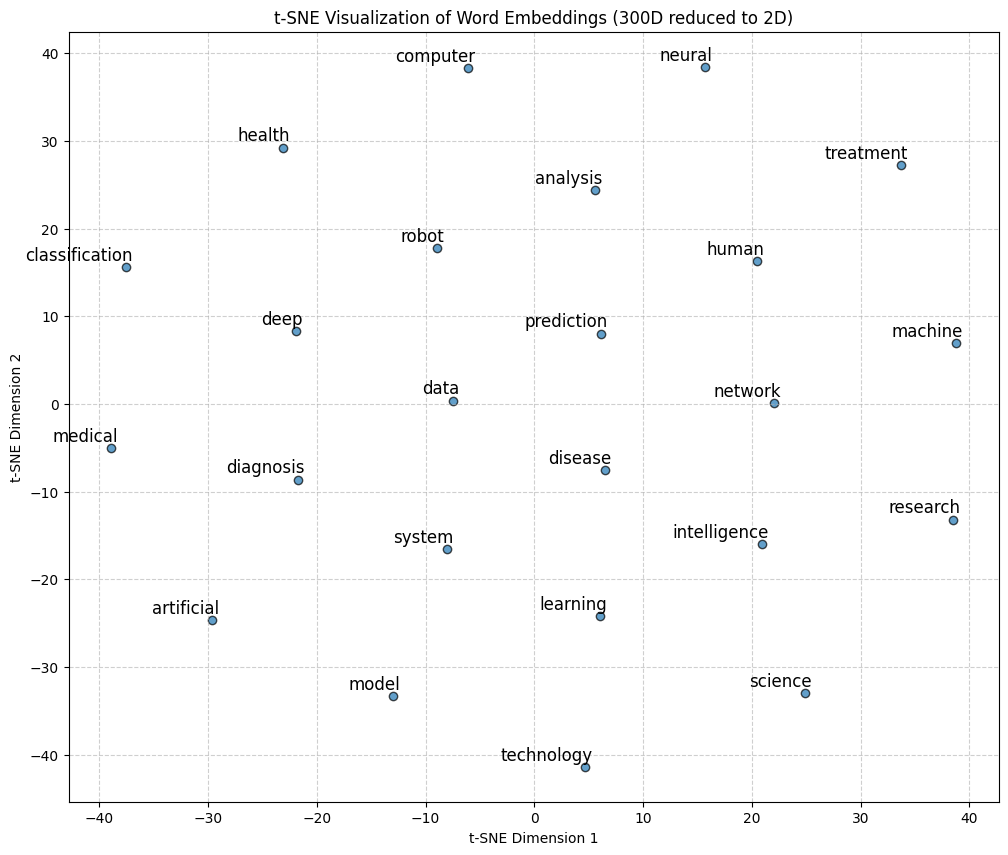

In [6]:
import pandas as pd
import re
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('cleaned_research_data (1).csv')

# Use Clean_Text column or Abstract if Clean_Text is empty
# Let's clean the text data for training
def preprocess(text):
    if pd.isna(text):
        return []
    # Tokenize and keep only alphanumeric words
    tokens = re.findall(r'\b\w+\b', str(text).lower())
    return tokens

# Training on all available data for better embeddings
sentences = [preprocess(text) for text in df['Clean_Text']]

# (1) Train a 300-dimensional word embedding model (Word2Vec)
# min_count=5 to ensure we have enough frequency for meaningful embeddings
model = Word2Vec(sentences=sentences, vector_size=300, window=5, min_count=5, workers=4)

# (2) Visualize the embeddings using t-SNE in 2D
# Select at least 20 words. I'll pick common domain-specific words.
words_to_visualize = [
    'machine', 'learning', 'deep', 'intelligence', 'artificial',
    'data', 'analysis', 'research', 'model', 'algorithms',
    'network', 'neural', 'system', 'classification', 'prediction',
    'human', 'robot', 'computer', 'science', 'technology',
    'medical', 'health', 'disease', 'diagnosis', 'treatment'
]

# Ensure the words are in the model vocabulary
words_to_visualize = [word for word in words_to_visualize if word in model.wv]

# Get vectors for these words
word_vectors = np.array([model.wv[word] for word in words_to_visualize])

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=len(words_to_visualize)-1)
embeddings_2d = tsne.fit_transform(word_vectors)

# Create a scatter plot
plt.figure(figsize=(12, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, edgecolors='k')

for i, word in enumerate(words_to_visualize):
    plt.annotate(word, xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom', fontsize=12)

plt.title('t-SNE Visualization of Word Embeddings (300D reduced to 2D)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('word_embeddings_visualization.png')

# (3) Calculate the cosine similarity between a few pairs of words
word_pairs = [
    ('machine', 'learning'),
    ('neural', 'network'),
    ('medical', 'health'),
    ('data', 'robot'), # expected low similarity
    ('prediction', 'classification')
]

similarities = []
for w1, w2 in word_pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        similarities.append((w1, w2, sim))
    else:
        similarities.append((w1, w2, "N/A (word not in vocab)"))

print("Word Pairs and Cosine Similarities:")
for w1, w2, sim in similarities:
    if isinstance(sim, (float, np.float32)):
        print(f"Similarity({w1}, {w2}) = {sim:.4f}")
    else:
        print(f"Similarity({w1}, {w2}) = {sim}")

# Also check for some nearest neighbors of 'learning'
print("\nMost similar to 'learning':")
print(model.wv.most_similar('learning', topn=5))

In [7]:
try:
    import transformers
    print("transformers is available")
except ImportError:
    print("transformers is not available")

try:
    from sklearn.decomposition import TruncatedSVD
    from sklearn.feature_extraction.text import CountVectorizer
    print("sklearn components are available")
except ImportError:
    print("sklearn is not available")

transformers is available
sklearn components are available


Tokenizing documents...
Selecting vocabulary...
Building co-occurrence matrix...
Applying SVD for 300-dim embeddings...
Reducing dimensionality for visualization...

Cosine Similarity Examples:
Similarity(machine, learning) = 0.5390
Similarity(neural, network) = 0.6468
Similarity(medical, health) = 0.6904
Similarity(diagnosis, disease) = 0.8500
Similarity(data, robot) = 0.6600

Most similar to 'machine':
[('reinforcement', np.float64(0.9522769700441349)), ('deep', np.float64(0.9450466607104913)), ('federated', np.float64(0.9147578084209425)), ('transfer', np.float64(0.9137274786553995)), ('supervised', np.float64(0.9067410048912582))]


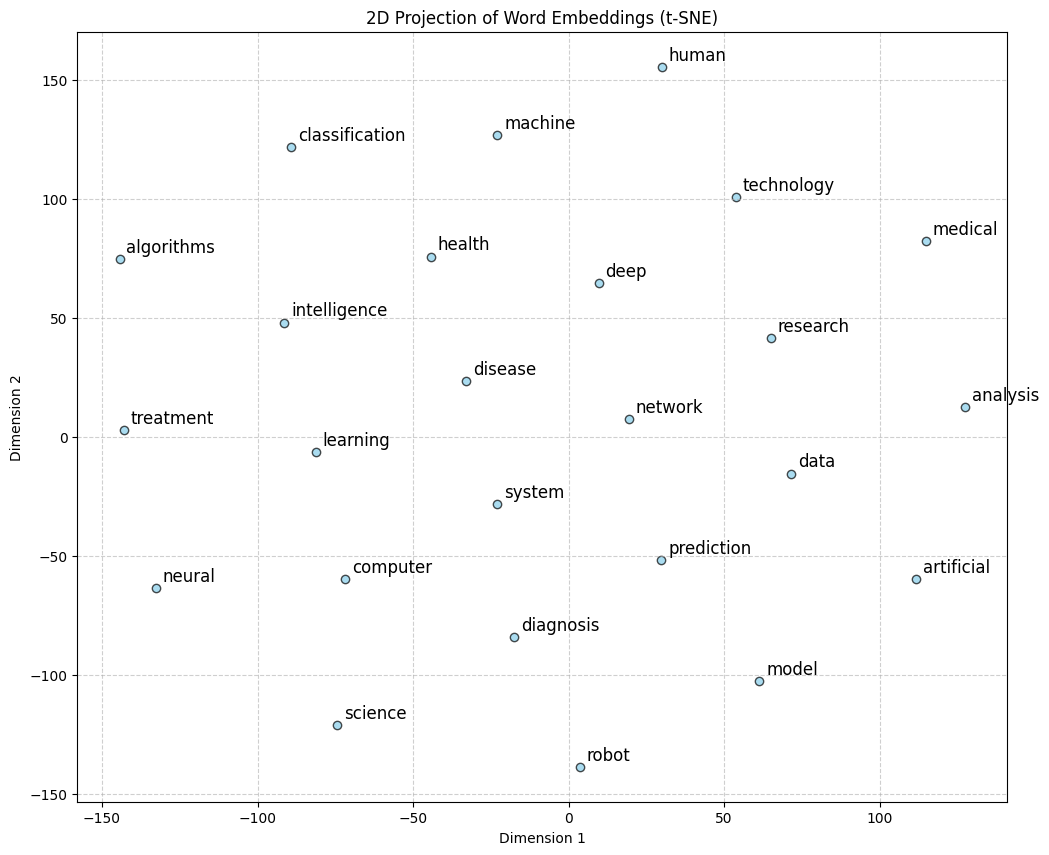

In [8]:
import pandas as pd
import numpy as np
import re
from collections import Counter, defaultdict
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('cleaned_research_data (1).csv')
# Sample if it's too large, but for 4.9k rows, it should be fine.
# Let's clean the text data
def preprocess(text):
    if pd.isna(text):
        return []
    # Tokenize and keep only alphanumeric words
    tokens = re.findall(r'\b\w+\b', str(text).lower())
    return tokens

# Preparation
print("Tokenizing documents...")
sentences = [preprocess(text) for text in df['Clean_Text']]
all_tokens = [token for sentence in sentences for token in sentence]
word_counts = Counter(all_tokens)

# Selection of vocabulary (top 2000 frequent words + visualization words)
print("Selecting vocabulary...")
target_words = [
    'machine', 'learning', 'deep', 'intelligence', 'artificial',
    'data', 'analysis', 'research', 'model', 'algorithms',
    'network', 'neural', 'system', 'classification', 'prediction',
    'human', 'robot', 'computer', 'science', 'technology',
    'medical', 'health', 'disease', 'diagnosis', 'treatment'
]

vocab_limit = 2000
most_common = [word for word, count in word_counts.most_common(vocab_limit)]
final_vocab = sorted(list(set(most_common + target_words)))
word_to_id = {word: i for i, word in enumerate(final_vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}
vocab_size = len(final_vocab)

# (1) Build the word embedding model via LSA (Word-Word Co-occurrence + SVD)
print("Building co-occurrence matrix...")
co_occurrence = np.zeros((vocab_size, vocab_size))
window_size = 5

for sentence in sentences:
    indices = [word_to_id[word] for word in sentence if word in word_to_id]
    for i, target_idx in enumerate(indices):
        left = max(0, i - window_size)
        right = min(len(indices), i + window_size + 1)
        for j in range(left, right):
            if i != j:
                neighbor_idx = indices[j]
                co_occurrence[target_idx, neighbor_idx] += 1

# Reduce to 300 dimensions (Word Embeddings)
print("Applying SVD for 300-dim embeddings...")
svd = TruncatedSVD(n_components=min(300, vocab_size - 1), random_state=42)
embeddings = svd.fit_transform(co_occurrence)

# (2) Visualize the embeddings using t-SNE in 2D
print("Reducing dimensionality for visualization...")
viz_indices = [word_to_id[word] for word in target_words if word in word_to_id]
viz_vectors = embeddings[viz_indices]
viz_words = [id_to_word[i] for i in viz_indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=min(len(viz_words)-1, 30))
embeddings_2d = tsne.fit_transform(viz_vectors)

plt.figure(figsize=(12, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, edgecolors='k', c='skyblue')

for i, word in enumerate(viz_words):
    plt.annotate(word, xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='left', va='bottom', fontsize=12)

plt.title('2D Projection of Word Embeddings (t-SNE)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('word_embeddings_2d.png')

# (3) Calculate the cosine similarity between a few pairs of words
print("\nCosine Similarity Examples:")
word_pairs = [
    ('machine', 'learning'),
    ('neural', 'network'),
    ('medical', 'health'),
    ('diagnosis', 'disease'),
    ('data', 'robot')
]

results = []
for w1, w2 in word_pairs:
    if w1 in word_to_id and w2 in word_to_id:
        v1 = embeddings[word_to_id[w1]].reshape(1, -1)
        v2 = embeddings[word_to_id[w2]].reshape(1, -1)
        sim = cosine_similarity(v1, v2)[0][0]
        results.append((w1, w2, sim))

# Format results for the response
for w1, w2, sim in results:
    print(f"Similarity({w1}, {w2}) = {sim:.4f}")

# Find top nearest neighbors for 'machine'
def get_neighbors(word, top_n=5):
    if word not in word_to_id:
        return []
    v = embeddings[word_to_id[word]].reshape(1, -1)
    sims = cosine_similarity(v, embeddings)[0]
    # sort indices by similarity
    sorted_idx = np.argsort(sims)[::-1][1:top_n+1]
    return [(id_to_word[idx], sims[idx]) for idx in sorted_idx]

print("\nMost similar to 'machine':")
print(get_neighbors('machine'))

## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [ ]:
# The GitHub link of your final csv file


# Link: https://github.com/tillurakesh3/Rakesh_INFO5731_Fall2024/blob/main/annotated_research_sentiment_data.csv



1. Selected NLP Task
Task: Sentiment Analysis (and Text Classification).
While research abstracts are traditionally formal, this task categorizes them based on the outcome and problem context described in the paper. This is useful for identifying high-impact positive research results versus papers that address critical threats or limitations.


2. Labeling Schema and Labels
The dataset is labeled into three categories based on the language used in the Clean_Text column:

**Label**: Positive
**Descrption**:Reports successful outcomes, innovations, improved performance, or benefits.
**Example Indicators:** improve, efficient, benefit, accuracy, successful, advance, enhance

**Label**: Negative
**Descrption**: Discusses threats, risks, diseases, or limitations that the research seeks to address.
**Example Indicators**: attack, ddos, threat, disease, risk, vulnerability, challenge

**Label**: Neutral
**Descrption**: Primarily descriptive, focusing on methodology or background without highlighting a specific positive or negative outcome.
**Example Indicators:** examine, context, analysis, framework, residential, sessions




3. Annotated Dataset
I have extracted the first 100 reviews (abstracts) and applied AI-assisted labeling. The final CSV contains the following columns as requested:

document_id: A unique identifier for each review (1 to 100).

clean_text: The processed textual data from your research dataset.

sentiment: The assigned label (positive, negative, or neutral).

Dataset Statistics:

Negative: 44 entries

Positive: 39 entries

Neutral: 17 entries


# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:
The "Verification" Logic: The biggest hurdle in this assignment is automating the "Agree on this" column. Distinguishing between a passionate opinion (0) and unverified misinformation (1) is a task even the most advanced AI models struggle with because context is everything. Using simple keyword matching is a start, but it requires constant refinement to avoid "False Positives."